In [ ]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

# Two-qubit gates with NMR

In this weeks lab, we are putting our expertise in NMR to perform controlled gates between two qubits. These are more recent developments in the field, with breakthroughs happening in the late 90's and full implementation of quantum algorithms in the 2000s.

You are encouraged to explore possible ways to perform each step, as multiple methods may exist. For each experiment, you will use a set of pulses to apply unitaries. First you should simulate the desired unitary action using the QuTiP package in python. You should argue why your proposed set of pulses should work and what kind of output you are expecting. Once this is done, run the experiment and discuss the results.

## Global phase shift

NMR detection is completely insensitive to global phase shifts on the density matrix. The density matrix of any isolated quantum system can be multiplied by an arbitrary phase shift without any observable effect, i.e. $|\psi\rangle$ and $e^{i\phi}|\psi\rangle$ are indistinguishable. Observe that
 $e^{i\phi}|\psi\rangle \langle\psi|e^{-i\phi}=|\psi\rangle \langle\psi|$

As an example, consider the square-root of the NOT gate, $ V^2=VV=N$, that may be implemented using $(\pi/2)_x$ rotations:
$$ V= \exp({-i \frac{\pi}{2} I_x})=\frac{1}{\sqrt{2}} \begin{pmatrix} 1 & -i \\ -i & 1 \end{pmatrix}.$$
This is equal to the ideal form $\frac{1}{2}\begin{pmatrix} 1+i & 1-i \\ 1-i & 1+i \end{pmatrix}$ up to a global phase of $\frac{1-i}{\sqrt{2}}$.


## The Hadamard gate

Hadamard gate H is famous for transforming eigenstates to superposition states. Recall that

$$ |0\rangle \overset{\text{H}} \longrightarrow (|0\rangle+|1\rangle)/\sqrt{2}$$
$$|1\rangle \overset{\text{H}} \longrightarrow (|0\rangle-|1\rangle)/\sqrt{2}.$$

H is self inverse so applying it twice is equivalent to the identity operator. 

In NMR, H can be implemented using an off-resonance x rotation
$$H=\exp({-i \frac{\pi}{\sqrt{2}} (I_x+I_z)})=\frac{1}{\sqrt{2}} \begin{pmatrix} -i & -i \\ -i & i  \end{pmatrix}$$
which has the correct form of H up to a global phase.

There are other pulse sets that realize such a unitary, e.g.
$$ (\frac{\pi}{4})_y -(\pi)_x-(\frac{\pi}{4})_{\bar{y}}$$
Note that this notation should be read from left to right. Also note that in this notation, $\bar{y} = -y$ or  $\frac{3\pi}{2}$ phase and $\bar{x} = -x $ or $\pi$ phase.
Show that the above sequence implements the Hadamard gate.

For our purpose, it is often easier to use a "pseudo-Hadamard" operator, h, which has the form:
$$\text{h}= \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ -1 & 1  \end{pmatrix}$$
This can be implemented with one $(\pi/2)_{\bar{y}}$ pulse. The difference from a real Hadamard is that this operator is not its own inverse. To get the inverse we should apply the same pulse with a positive sign, h$^{-1}=(\pi/2)_{y}$.

### Exp1) Optimizing Hadamard gate:

One effective method for characterizing errors in the application of quantum gates is to analyze the outcome of repeatedly applying the same gate, thereby amplifying small inaccuracies in pulse length, amplitude, or phase. For instance, consider a gate that is ideally self-inverse, such as the Hadamard gate ($H$, where $H^2 = I$). In the ideal case, an even number of perfect Hadamard applications should return the system to its initial state. However, if the pulses are slightly off, the accumulated errors will degrade the fidelity (i.e., the overlap with the expected state) as the number of applications increases.

To observe this behavior, modify the standard CPMG experiment (e.g., the T2Bulk pulse program) so that it applies a sequence of "pseudo-Hadamard'' operations, implemented as $(\pi/2)_{\bar{y}}$ pulses. In this modified sequence, record two data points during the interval between successive pulses.

Consider an ideal sequence of $(\pi/2)_{\bar{y}}$ pulses. How does the magnetization vector evolve on the Bloch sphere, and how is this evolution reflected in the measured data? Ideally, the vector should follow a predictable trajectory such that, after every 4 pulses (completing an identity cycle), it returns to its initial state.

What limits the number of gates that can be applied before the signal decay? In practice, decoherence effects (such as $T_2$ relaxation) and cumulative pulse imperfections (errors in pulse length, amplitude, or phase) restrict the number of reliable gate operations.

Can the performance of the $(\pi/2)_{\bar{y}}$ (pseudo-Hadamard) gate be improved by fine-tuning the pulse length and amplitude? Optimizing these parameters should enhance the fidelity of the gate and reduce the error accumulation over repeated applications.

What is an appropriate metric to quantify the errors associated with an individual gate? Metrics such as the per-gate fidelity or the decay rate of the signal amplitude as a function of the number of cycles can provide a quantitative measure of gate performance. Can you report on the gate improvement by comparing your optimized gate with the result of the PulseDuration experiment?


Finally, repeat the experiment using the true Hadamard gate. 


## The Controlled-NOT gate

The fundamental two-qubit gate is the CNOT gate which applies a NOT gate to the target qubit if the control qubit is in the $|0\rangle$ state.

It is well known that controlled gates, such as CNOT, are related to controlled phase shift by the Hadamard transform.

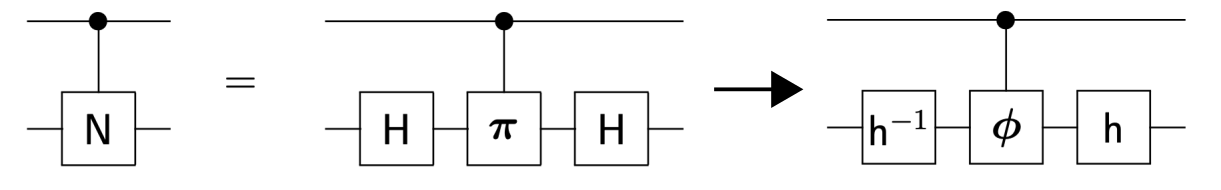

In [ ]:
Image(filename='Image900.png',  width=600, height=100)

Where the  Hadamard  gates are being replaced by their "pseudo" version and the controlled-z gate is  $$  \pi=\begin{pmatrix} 1&0&0&0\\0&1&0&0\\0&0&1&0\\0&0&0&-1  \end{pmatrix}$$.

Also recall that rotations along the z axis can be applied with composite pulses:
$$ (\theta)_z=(\pi/2)_{\bar{x}}-(\theta)_{y}-(\pi/2)_{x}$$

As you have seen in the prelab question for this lab, the controlled-z gate is relatively simple to apply. You have a sum of $I_z^1$ hydrogen operators, and $I_z^2$ carbon operators, that can be implemented as periods of free precession or by using composite pulses. The $2I_z^1I_z^2$ term is applied using the j-coupling.

### Exp2) CNOTappx gate

First show that the following sequence results in the controlled-z gate:
$$ (\pi/2I_z^1)-(\pi/2I_z^2)-(-2I_z^1I_z^2)$$.


Then evaluate the following operator and show that it is similar to the CNOT gate:
    $$CNOTappx= (\pi/2I_x^2)-(2I_z^1I_z^2)-(\pi/2I_y^2)$$

Write down the pulse program for implementing this sequence. Write two versions where the reciever is either placed on the 1H or 13C channel. Remember to apply a $(\pi/2)_x$ detection pulse to the appropriate channel before opening the reciever.

Save copies of the "1H_Pulsing_Template" and "13C_Pulsing_Template" from the Template menu to your group's folder. These 2 versions are set up to work for their respective channels, so only the pulse program should need to be added. Remember to calibrate the receiver phase and center PPM, which can be done by writing an FID in your program. The default values for several parameters are provided, but these can vary based on the sample as you have seen in labs 1 and 2.
You may use the values you calibrated in lab 2 or recalibrate values using the same experiment files you used during those labs.

It is highly recommended that you start by setting up and testing your pulse sequences in the "1H_Pulsing_Template" before using them in your version of the "13C_Pulsing_Template", as experiments in 13C will take a long time due to the increased T1 time and decreased signal strength (AKA more scans are needed to overcome noise). Also keep in mind that when pulsing on both 13C and 1H at the same time you need to be sure that you wait for both the 1H and 13C to fully recover. This means that in these cases, you need to take the longer 13C T1 time into account even when only receiving on the 1H channel.

Apply your pulse sequence to the thermal state and record both the 1H and 13C spectra. What should the spectra look like?

Quality of life note: If there is a setting in the interface you want to change the default of, go to the "default settings" tab and replace the variable value with the value you want it to default to when opening a new instance of the program. Then hit "ctrl + s" and compile. If the value is listed as "factory" you will also need to enter the "pulse programming" tab and scroll all the way to the bottom. Remove the variable you hardcoded a value for from the factory settings list. This will allow you to not have to always re-enter values when you click off your pulse program and should make your life easier once you've calculated/experimentally determined various values, such as the proper center PPM for 1H and 13C as well as the evolution time of your sample.

### Exp3) CNOT gate

Use the operator from the first experiment and find a sequence of pulses that implements the exact CNOT gate. You should be able to do this by adding only two extra  pulses. Show that the unitary for your pulse sequence is identical to the CNOT gate.

Write the pulse program for implementation of the CNOT gate. Again write two versions with detection on 1H and 13C channels. Remember that you can comment a line using the "#" symbol, so the CNOT and CNOTapprx can be done in the same template if this is perffered.

Apply the CNOT pulse sequence on the thermal state and record both proton and carbon spectra. What should the spectra look like?

## Pseudo-pure state

We are using temporal average method for creating pseudo-pure states. As you worked out in the prelab questions, we need two set of permutations $P_1$ and $P_2$ , to properly average the diagonal components of the density matrix.  

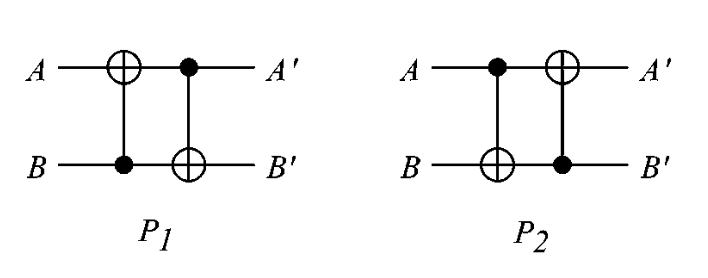

In [ ]:
Image(filename='permts.png',  width=600, height=100)

First show that these two permutations are correspondant to the following pulse sequences:

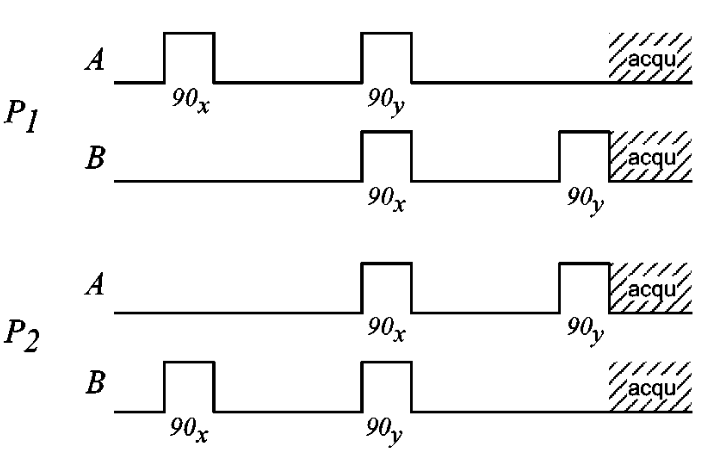

In [ ]:
    Image(filename='ppgpermts.png',  width=600, height=100)

### Exp4) Pseudo-pure state

Write the pulse program for implemeentation of $P_1$ and $P_2$.

When you have coinciding pulses on both channels you may apply pulses in the following form:

      (90-H and 90-C pulse)
      pulse(1,a90HC,p2,freq1H,2,a90C,p1,freq13C,d90C)
      
Note that both of the pulses are using the same delay, d90C. "AmplitudeHC" parameter should be calibrated for that pulse length.

### Exp5) Truth table

Prepare all the four possible classical states $\{|00\rangle,|01\rangle,|10\rangle,|11\rangle\}$ using temporal averaging. Apply CNOT and CNOTappx gates and make a truth table.

## Exp6) Optional

write a script that combines the result of different permutations and average them, giving the pseudo-pure state as the output.